In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("us-superstore_data_limpo.csv")
display(df)

,Row ID,Order Date,City,State,Category,Sub-Category,Sales,Quantity,Profit,Year_Month
0,8,2014-06-09,Los Angeles,California,Technology,Phones,907.152,6,90.7152,2014-06
1,12,2014-06-09,Los Angeles,California,Technology,Phones,911.424,4,68.3568,2014-06
2,20,2014-08-27,San Francisco,California,Technology,Phones,213.480,3,16.0110,2014-08
3,27,2016-01-16,Los Angeles,California,Technology,Accessories,90.570,3,11.7741,2016-01
4,41,2015-12-27,Houston,Texas,Technology,Phones,371.168,4,41.7564,2015-12
...,...,...,...,...,...,...,...,...,...,...
1540,9984,2016-09-22,Grand Rapids,Michigan,Technology,Phones,97.980,2,27.4344,2016-09
1541,9987,2016-09-29,Los Angeles,California,Technology,Accessories,36.240,1,15.2208,2016-09
1542,9988,2017-11-17,Athens,Georgia,Technology,Accessories,79.990,1,28.7964,2017-11
1543,9989,2017-11-17,Athens,Georgia,Technology,Phones,206.100,5,55.6470,2017-11


## Heatmap para visualizar a correlação das variaveis númericas

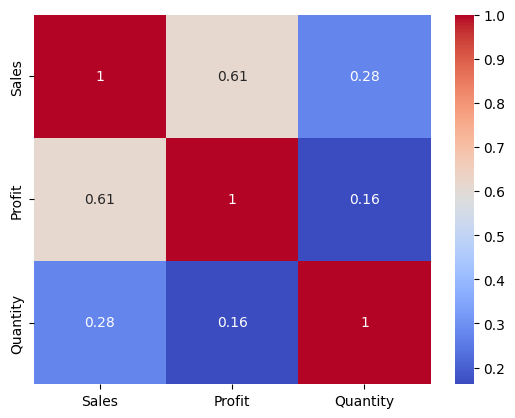

In [71]:
sns.heatmap(df[["Sales", "Profit", "Quantity"]].corr(), annot=True, cmap="coolwarm")
plt.show()

## Criando Colunas Relevantes para a Analise

In [72]:
# Fazendo copia do DataSet
df_normalizado = df.copy()

# Margem de Lucro
df_normalizado["Profit_Margim"] = df_normalizado["Profit"] / df_normalizado["Sales"]

# Lucro por Unidade
df_normalizado["Profit_por_Unidade"] = df_normalizado["Profit"] / df_normalizado["Quantity"]

# Vendas por Unidade
df_normalizado["Sales_por_Unidade"] = df_normalizado["Sales"] / df_normalizado["Quantity"]

## Normalização dos Dados

In [73]:
# Variavel com a função
robustScaler = RobustScaler()

# Normalizando as colunas 
df_normalizado["Label_Profit"] = robustScaler.fit_transform(df_normalizado[["Profit"]])
df_normalizado["Label_Sales"] = robustScaler.fit_transform(df_normalizado[["Sales"]])
df_normalizado["Sales_por_Unidade_nor"] = robustScaler.fit_transform(df_normalizado[["Sales_por_Unidade"]])

In [74]:
# Variavel com a função
le = LabelEncoder()

# Transformando variaveis categoricas a númericas
df_normalizado["Label_State"] = le.fit_transform(df_normalizado["State"])

df_normalizado["Label_Sub-Category"] = le.fit_transform(df_normalizado["Sub-Category"])
display(df_normalizado)

,Row ID,Order Date,City,State,Category,Sub-Category,Sales,Quantity,Profit,Year_Month,Profit_Margim,Profit_por_Unidade,Sales_por_Unidade,Label_Profit,Label_Sales,Sales_por_Unidade_nor,Label_State,Label_Sub-Category
0,8,2014-06-09,Los Angeles,California,Technology,Phones,907.152,6,90.7152,2014-06,0.1000,15.1192,151.192,1.550928,3.483038,1.410621,3,3
1,12,2014-06-09,Los Angeles,California,Technology,Phones,911.424,4,68.3568,2014-06,0.0750,17.0892,227.856,1.060795,3.502042,2.393997,3,3
2,20,2014-08-27,San Francisco,California,Technology,Phones,213.480,3,16.0110,2014-08,0.0750,5.3370,71.160,-0.086711,0.397171,0.384043,3,3
3,27,2016-01-16,Los Angeles,California,Technology,Accessories,90.570,3,11.7741,2016-01,0.1300,3.9247,30.190,-0.179591,-0.149606,-0.141483,3,0
4,41,2015-12-27,Houston,Texas,Technology,Phones,371.168,4,41.7564,2015-12,0.1125,10.4391,92.792,0.477671,1.098661,0.661519,39,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1540,9984,2016-09-22,Grand Rapids,Michigan,Technology,Phones,97.980,2,27.4344,2016-09,0.2800,13.7172,48.990,0.163709,-0.116642,0.099666,19,3
1541,9987,2016-09-29,Los Angeles,California,Technology,Accessories,36.240,1,15.2208,2016-09,0.4200,15.2208,36.240,-0.104034,-0.391299,-0.063879,3,0
1542,9988,2017-11-17,Athens,Georgia,Technology,Accessories,79.990,1,28.7964,2017-11,0.3600,28.7964,79.990,0.193566,-0.196672,0.497306,8,0
1543,9989,2017-11-17,Athens,Georgia,Technology,Phones,206.100,5,55.6470,2017-11,0.2700,11.1294,41.220,0.782176,0.364340,0.000000,8,3


In [76]:
df_normalizado.to_csv("../Machine_Learning/us_superstore_data_normalizado.csv")